# OpenVLA — Visual Experiments

> **Goal:** See how OpenVLA turns robot actions into tokens and fuses two vision encoders — the design choices a VLA ModelAdapter must capture.

## What we'll explore

| # | Experiment | Question answered |
|---|---|---|
| 1 | **Action as tokens** | How does per-dimension binning turn a 7-DoF action into discrete tokens? |
| 2 | **Categorical action head** | Why does a categorical head beat regression on multimodal actions? |
| 3 | **Bins vs precision** | How does the number of bins trade control precision against vocabulary size? |
| 4 | **Dual vision encoder** | Why fuse DINOv2 (spatial) and SigLIP (semantic) instead of using one? |

---
**Linked theory:** [research/06-openvla.md](../research/06-openvla.md)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.35,
})
print('Setup complete.')

Setup complete.


---
## Experiment 1: Action as tokens

**Question:** OpenVLA predicts a 7-DoF action as 7 discrete tokens, each dimension binned into 256 values. What does that binning look like?

We take continuous actions, bin each dimension into 256 percentile bins, and show the token representation and the quantization error.

In [2]:
np.random.seed(1)

dof_names = ['Δx', 'Δy', 'Δz', 'roll', 'pitch', 'yaw', 'grip']
n, B = 4000, 256
# continuous 7-DoF action data with different scales per dimension
actions = np.random.randn(n, 7) * np.array([0.05, 0.05, 0.03, 0.2, 0.2, 0.3, 1.0])

# per-dimension percentile bin edges (data-dependent, like OpenVLA)
edges = [np.quantile(actions[:, d], np.linspace(0, 1, B + 1)) for d in range(7)]


def tokenize(a):
    toks, recon = [], []
    for d in range(7):
        k = np.clip(np.searchsorted(edges[d], a[d]) - 1, 0, B - 1)
        centre = 0.5 * (edges[d][k] + edges[d][k + 1])
        toks.append(k); recon.append(centre)
    return np.array(toks), np.array(recon)


example = actions[0]
tok, recon = tokenize(example)
print('continuous action:', np.round(example, 3))
print('action tokens     :', tok)
print('detokenized       :', np.round(recon, 3))

continuous action: [ 0.081 -0.031 -0.016 -0.215  0.173 -0.69   1.745]
action tokens     : [243  69  72  37 206   2 245]
detokenized       : [ 0.082 -0.03  -0.016 -0.212  0.173 -0.684  1.757]


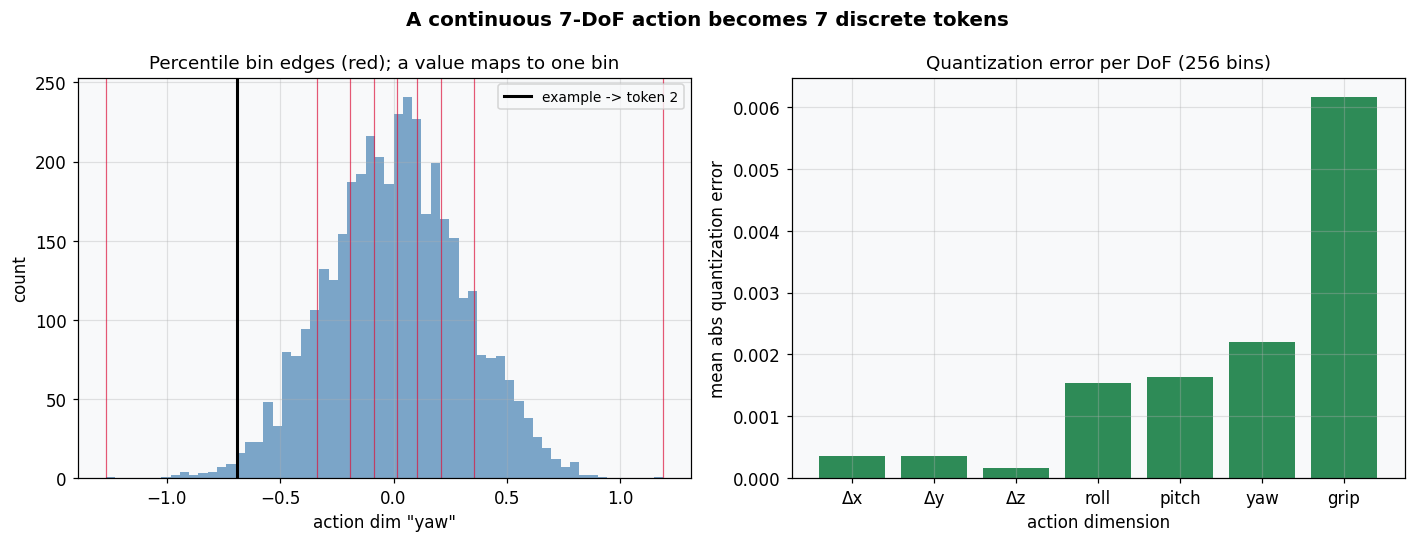

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('A continuous 7-DoF action becomes 7 discrete tokens', fontsize=13, fontweight='bold')

ax = axes[0]
d = 5   # yaw dimension
ax.hist(actions[:, d], bins=60, color='steelblue', alpha=0.7)
for q in np.quantile(actions[:, d], np.linspace(0, 1, 9)):
    ax.axvline(q, color='crimson', lw=0.8, alpha=0.7)
ax.axvline(example[d], color='black', lw=2, label=f'example -> token {tok[d]}')
ax.set_xlabel(f'action dim "{dof_names[d]}"'); ax.set_ylabel('count')
ax.set_title('Percentile bin edges (red); a value maps to one bin')
ax.legend(fontsize=9)

ax2 = axes[1]
errs = np.array([np.abs(a - tokenize(a)[1]) for a in actions[:500]]).mean(0)
ax2.bar(dof_names, errs, color='seagreen')
ax2.set_ylabel('mean abs quantization error'); ax2.set_xlabel('action dimension')
ax2.set_title(f'Quantization error per DoF ({B} bins)')

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The left panel shows one action dimension's distribution split by percentile bin edges (red); the example value falls into a single bin (token). The right panel shows the per-dimension quantization error is tiny with 256 bins, scaled to each DoF's natural range.
2. **Why it looks this way:** Percentile binning places bins where the data density is, so each of the 256 tokens covers an equal share of actions and the reconstruction (bin centre) is close to the true value.
3. **Key takeaway:** Each action becomes 7 integer tokens, letting the LLM predict actions with the very same next-token machinery it uses for text — the core of OpenVLA.

---
## Experiment 2: Categorical action head

**Question:** When a situation admits two valid actions (grasp from the left or the right), a regression head outputs their average — often an invalid action. How does a categorical (token) head help?

We compare a categorical distribution over action bins to a single MSE-regression output on a bimodal action.

In [4]:
np.random.seed(2)

# two equally valid grasp angles: -0.6 and +0.6 rad; the middle (0) misses the object
valid = np.where(np.random.rand(6000) < 0.5, -0.6, 0.6) + 0.05 * np.random.randn(6000)
B = 41
bins = np.linspace(-1, 1, B)
cat = np.histogram(valid, bins=B, range=(-1, 1))[0] / len(valid)
centres = 0.5 * (np.linspace(-1, 1, B + 1)[:-1] + np.linspace(-1, 1, B + 1)[1:])
mse_output = valid.mean()    # what a regression head learns
print(f'regression head output: {mse_output:.2f}  (near 0 -> misses the object)')

regression head output: -0.02  (near 0 -> misses the object)


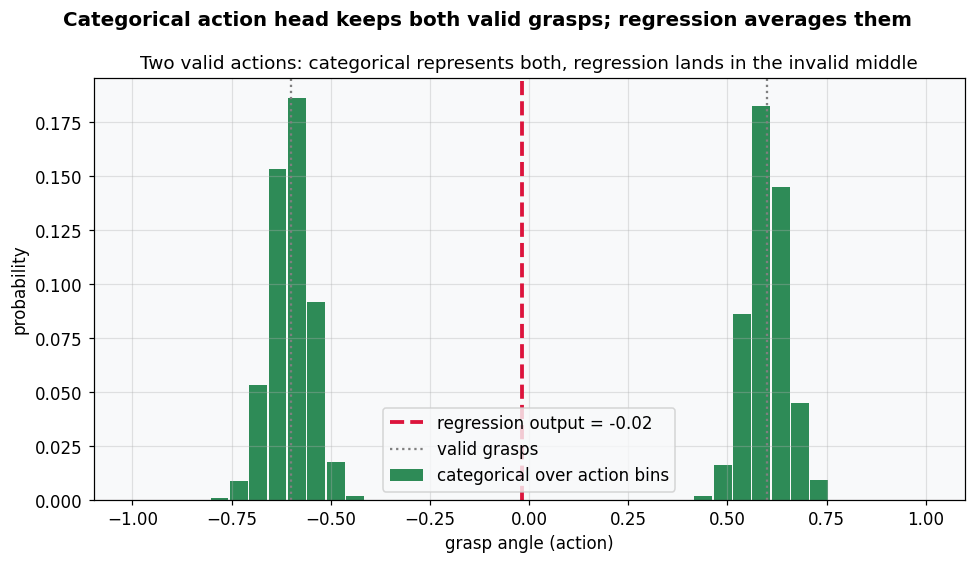

In [5]:
fig, ax = plt.subplots(figsize=(9, 5.2))
fig.suptitle('Categorical action head keeps both valid grasps; regression averages them', fontsize=13, fontweight='bold')

ax.bar(centres, cat, width=0.045, color='seagreen', label='categorical over action bins')
ax.axvline(mse_output, color='crimson', ls='--', lw=2.5, label=f'regression output = {mse_output:.2f}')
ax.axvline(-0.6, color='gray', ls=':', lw=1.5); ax.axvline(0.6, color='gray', ls=':', lw=1.5, label='valid grasps')
ax.set_xlabel('grasp angle (action)'); ax.set_ylabel('probability')
ax.set_title('Two valid actions: categorical represents both, regression lands in the invalid middle')
ax.legend()

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The categorical head (green) has two clean peaks at −0.6 and +0.6 — both valid grasps — while the regression output (red dashed) sits at ≈0, between the modes, where the gripper would miss.
2. **Why it looks this way:** A categorical distribution over bins can place mass on multiple discrete actions; a regression head can only output one number, so it averages the modes into an action that occurs in neither.
3. **Key takeaway:** Discretizing actions into tokens lets OpenVLA represent multimodal action distributions — the same multimodal advantage discrete latents gave DreamerV2 and tokenized world models.

---
## Experiment 3: Bins vs precision

**Question:** More bins mean finer control but a larger action vocabulary. How does the bin count trade off against control precision?

We measure the worst-case quantization error (control precision) as a function of the number of bins.

In [6]:
np.random.seed(3)

dim = np.random.randn(8000) * 0.3
bin_counts = [4, 8, 16, 32, 64, 128, 256]
max_err, mean_err = [], []
for B in bin_counts:
    e = np.quantile(dim, np.linspace(0, 1, B + 1))
    k = np.clip(np.searchsorted(e, dim) - 1, 0, B - 1)
    centre = 0.5 * (e[k] + e[k + 1])
    max_err.append(np.abs(dim - centre).max())
    mean_err.append(np.abs(dim - centre).mean())
print('bins      :', bin_counts)
print('max error :', np.round(max_err, 4))

bins      : [4, 8, 16, 32, 64, 128, 256]
max error : [0.5163 0.4473 0.3878 0.3392 0.2999 0.2565 0.2239]


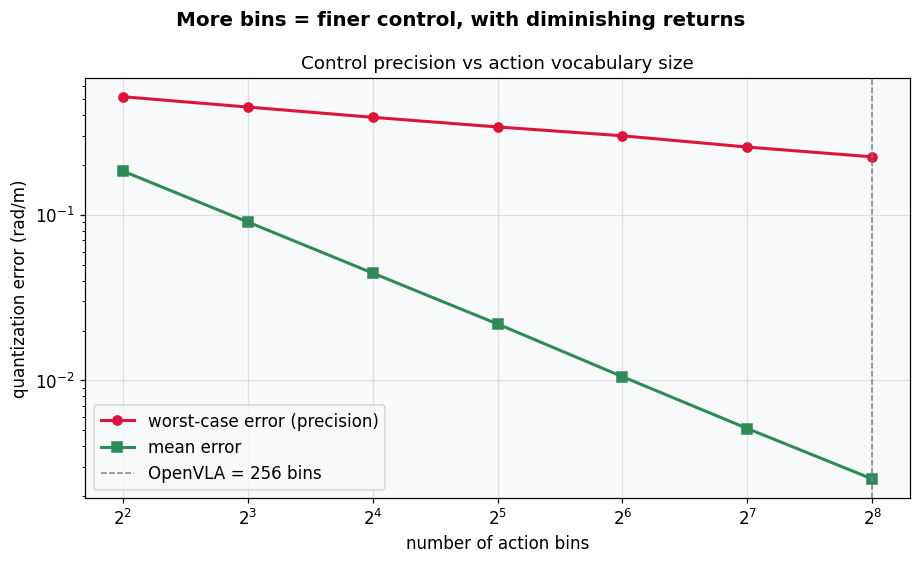

In [7]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))
fig.suptitle('More bins = finer control, with diminishing returns', fontsize=13, fontweight='bold')

ax.plot(bin_counts, max_err, '-o', color='crimson', lw=2, label='worst-case error (precision)')
ax.plot(bin_counts, mean_err, '-s', color='seagreen', lw=2, label='mean error')
ax.axvline(256, color='gray', ls='--', lw=1, label='OpenVLA = 256 bins')
ax.set_xlabel('number of action bins'); ax.set_ylabel('quantization error (rad/m)')
ax.set_xscale('log', base=2); ax.set_yscale('log')
ax.set_title('Control precision vs action vocabulary size')
ax.legend()

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** Both worst-case and mean quantization error fall as bins increase, roughly halving each time the bin count doubles, and flatten in relative terms by 256 bins.
2. **Why it looks this way:** Doubling the bins halves each bin's width, so the maximum error (half a bin) halves too. 256 bins makes the residual error small enough that discretization rarely limits the task.
3. **Key takeaway:** 256 bins is a sweet spot — fine enough for most manipulation, coarse enough to fit cheaply into the LLM vocabulary. Tasks needing sub-bin precision motivate continuous action heads (π0).

---
## Experiment 4: Dual vision encoder

**Question:** OpenVLA fuses DINOv2 (strong spatial/geometric features) and SigLIP (strong semantic features). Why use both instead of one?

We build a task that needs *both* an object's position and its category. One encoder captures only position, the other only category. We probe how well each alone — and the fusion — predicts the task.

In [8]:
np.random.seed(4)

n = 2000
position = np.random.randint(0, 2, n)     # left / right (spatial)
category = np.random.randint(0, 2, n)     # cup / ball (semantic)
task = position * 2 + category            # 4 distinct tasks need BOTH

# DINOv2-like encoder: encodes position, blind to category
dino = np.stack([position, 0.3 * np.random.randn(n)], 1) + 0.1 * np.random.randn(n, 2)
# SigLIP-like encoder: encodes category, blind to position
siglip = np.stack([category, 0.3 * np.random.randn(n)], 1) + 0.1 * np.random.randn(n, 2)
fused = np.concatenate([dino, siglip], 1)


def probe_acc(X):
    clf = LogisticRegression(max_iter=500).fit(X[:1500], task[:1500])
    return clf.score(X[1500:], task[1500:])


accs = {'DINOv2 only': probe_acc(dino), 'SigLIP only': probe_acc(siglip), 'fused (both)': probe_acc(fused)}
for k, v in accs.items():
    print(f'{k:14s}: {v:.2f}')

DINOv2 only   : 0.52
SigLIP only   : 0.50
fused (both)  : 1.00


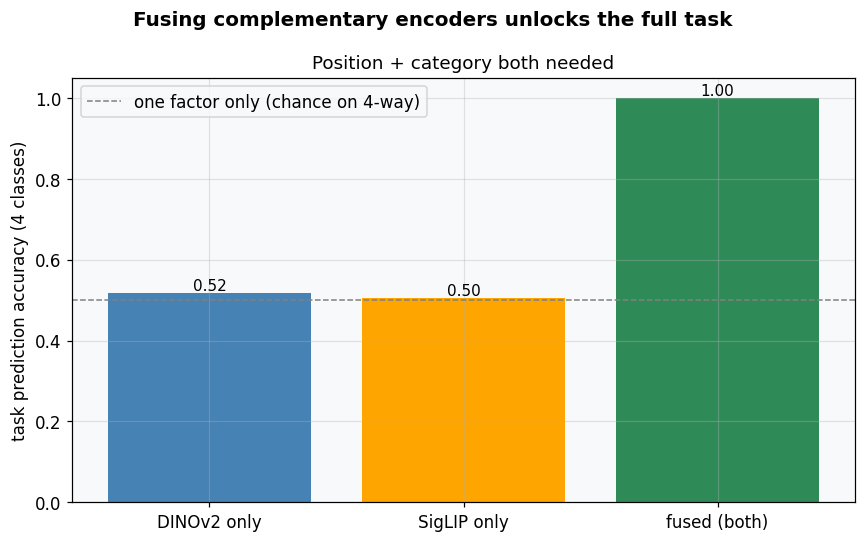

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle('Fusing complementary encoders unlocks the full task', fontsize=13, fontweight='bold')

names = list(accs.keys()); vals = list(accs.values())
bars = ax.bar(names, vals, color=['steelblue', 'orange', 'seagreen'])
ax.axhline(0.5, color='gray', ls='--', lw=1, label='one factor only (chance on 4-way)')
ax.set_ylabel('task prediction accuracy (4 classes)'); ax.set_ylim(0, 1.05)
ax.set_title('Position + category both needed')
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{v:.2f}', ha='center', va='bottom', fontsize=10)
ax.legend()

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** Either encoder alone reaches only ≈50% on the 4-way task (it can recover one factor but not the other), while the fused representation reaches near 100%.
2. **Why it looks this way:** The task needs both position and category; DINOv2-like features supply spatial information, SigLIP-like features supply semantics. Only their concatenation contains both, so only the fusion can solve every case.
3. **Key takeaway:** OpenVLA fuses two pretrained encoders because spatial and semantic cues are complementary — a single encoder leaves half the task information on the table.

---
## Summary

| Experiment | Key insight |
|---|---|
| 1. Action as tokens | Per-dimension percentile binning turns a 7-DoF action into 7 low-error tokens the LLM can predict. |
| 2. Categorical action head | A categorical head represents multimodal actions; regression averages valid actions into invalid ones. |
| 3. Bins vs precision | 256 bins balances fine control against a compact action vocabulary. |
| 4. Dual vision encoder | DINOv2 (spatial) + SigLIP (semantic) are complementary; fusion solves tasks neither can alone. |

### Connection to the broader theory

OpenVLA extends the Tier 9 idea — discretize, then reuse the LLM — to *actions*, binning each DoF into [scalar-quantized](../../09-discrete-latent/research/06-finite-scalar-quantization.md) tokens. This makes both observation and action a unified token stream, the cleanest VLA `ModelAdapter` shape. The next topic, **π0**, takes the opposite route for actions: a continuous flow-matching head for smooth, high-precision control.